In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = fetch_openml(name = 'creditcard', version=1, as_frame=True)
df = data.frame.copy()
df.head(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
#Variance
from sklearn.feature_selection import VarianceThreshold

X = df.drop("Class", axis=1)
Y = df['Class']

# Verificar variância
variances = X.var().sort_values()
print("Features com menor variância:")
print(variances.head(29))

# Remover features com variância < threshold
selector = VarianceThreshold(threshold=0.1)
X_variance = selector.fit_transform(X)

print(f"\nFeatures originais: {X.shape[1]}")
print(f"Features após filtro: {X_variance.shape[1]}")


Features com menor variância:
V28           0.108955
V27           0.162919
V26           0.232543
V25           0.271731
V24           0.366808
V23           0.389951
V22           0.526643
V21           0.539526
V20           0.594325
V19           0.662662
V18           0.702539
V17           0.721373
V16           0.767819
V15           0.837803
V14           0.918906
V13           0.990571
V12           0.998403
V11           1.041855
V10           1.185594
V9            1.206992
V8            1.426479
V7            1.530401
V6            1.774946
V5            1.905081
V4            2.004684
V3            2.299029
V2            2.726820
V1            3.836489
Amount    62560.069046
dtype: float64

Features originais: 29
Features após filtro: 29


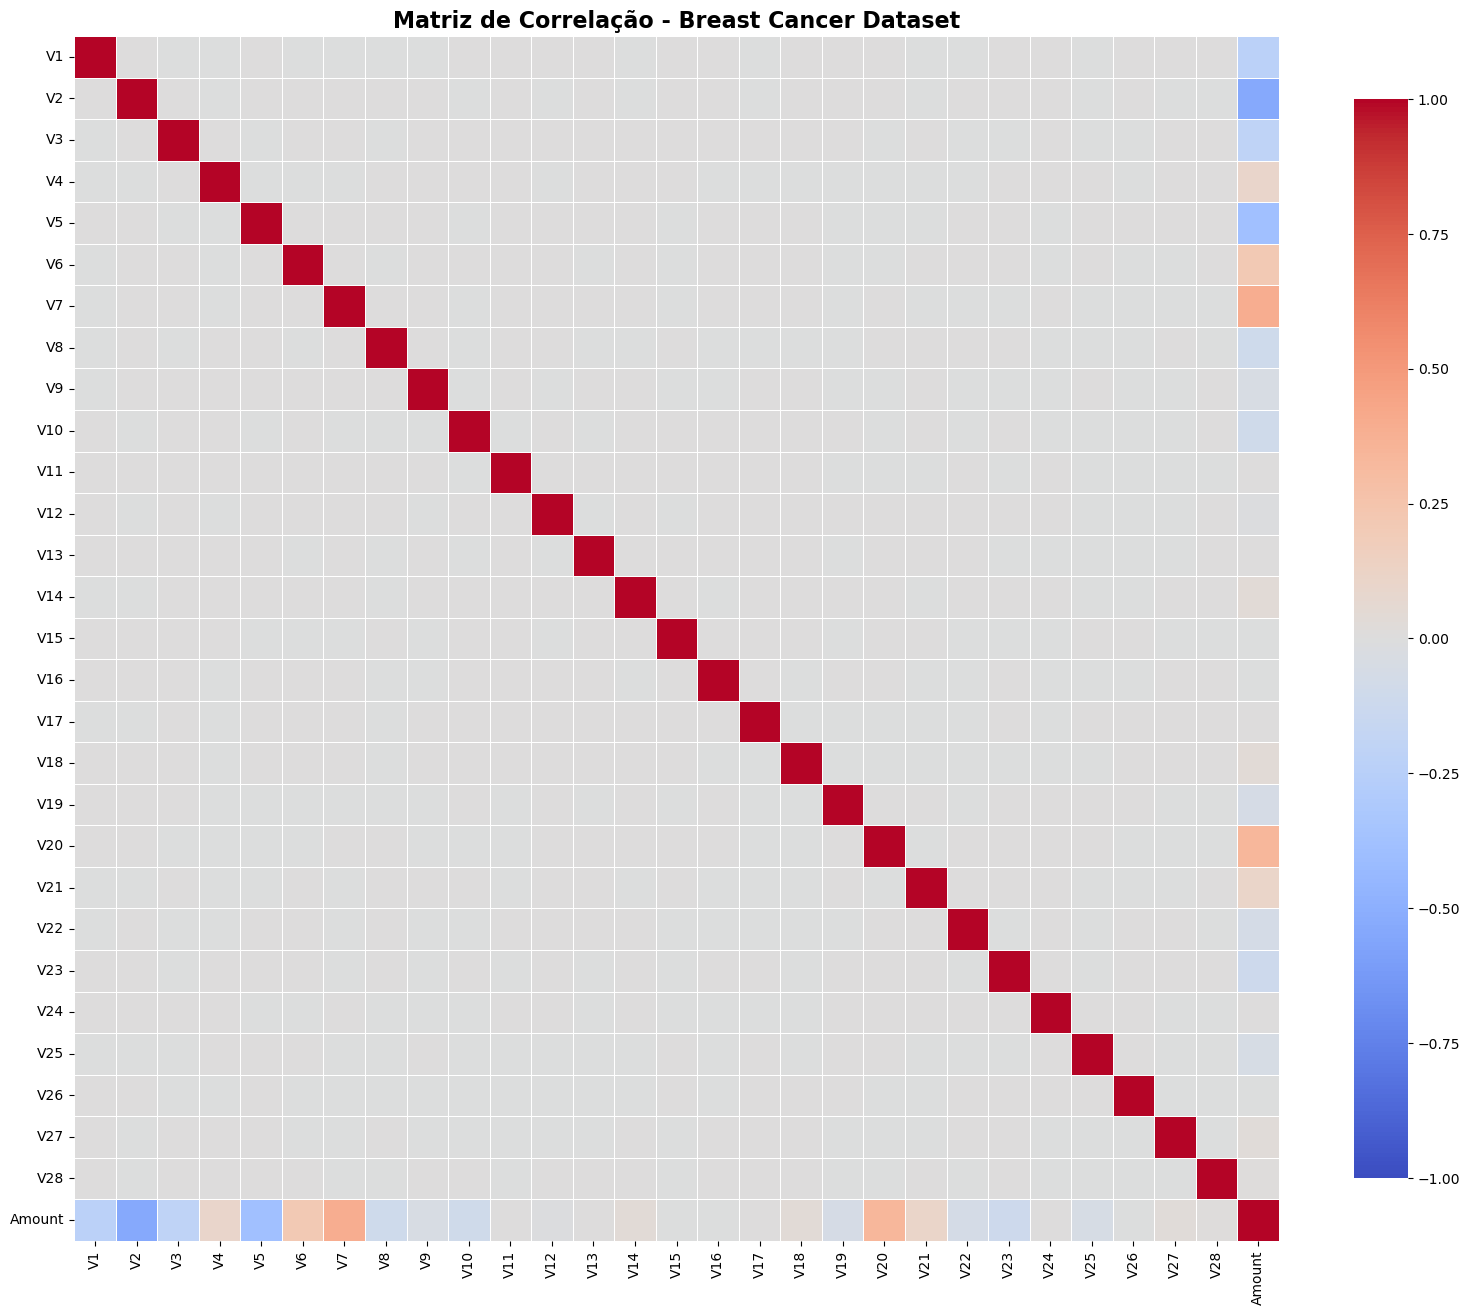

In [10]:
#Peason
import seaborn as sns
import numpy as np

# 1. CALCULAR MATRIZ DE CORRELAÇÃO
correlation_matrix = X.corr()


# Visualizar
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Breast Cancer Dataset', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. IDENTIFICAR CORRELAÇÕES ALTAS
def find_high_correlations(correlation_matrix, threshold=0.9):
    # Criar cópia da matriz
    corr_matrix = correlation_matrix.abs()

     # Pegar apenas triângulo superior (evitar duplicatas)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

     # Encontrar pares com alta correlação
    high_corr_pairs = []

In [ ]:
#RFE
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Criar modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# RFE - selecionar 10 melhores features
rfe_rf = RFE(estimator=rf_model, n_features_to_select=10, step=1)
rfe_rf.fit(X, Y)

# Resultados RFE
resultados_rfe = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe_rf.ranking_,
    'Selecionada': rfe_rf.support_
}).sort_values('Ranking')

print(resultados_rfe)

In [ ]:
#Os outros 3: Lasso, XGBoost e Random Forest

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

#  1. LASSO 
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, Y)


lasso_importance = pd.DataFrame({ 'Feature': X.columns,'Lasso': np.abs(lasso.coef_)})

#  2. RANDOM FOREST 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, Y)

rf_importance = pd.DataFrame({'Feature': X.columns, 'Random Forest': rf.feature_importances_})

#  3. XGBOOST 
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_scaled, Y)

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'XGBoost': xgb.feature_importances_
})